# Performance Curves

Generates the main performance curves for all six datasets (Figure 2 in the paper).
Reads MLflow experiments `final-3-{dataset}-25` and produces retention curves
for CDVM, pruning, DataOOB, Banzhaf, and Random baselines.

**Input:** MLflow experiments `final-3-{dataset}-25`, `cifar10-embeddings-DataAttributionOptimization-[2000]-10`  
**Output:** `output/{dataset}.pdf`, monotonicity and baseline comparison plots

In [1]:
import matplotlib.pyplot as plt
import mlflow

from utils_run import get_single_result_table
from utils_plot import find_run, get_and_preprocess_run

Connected to local server. http://localhost:5000


## Configuration

In [2]:
RUN_SPECS = {#"DataAttrOpt(10000, 0.1, 15, best, +b, alpha=best)": ["CDVM(10k)", "-", "blue"],
             "DataAttrOpt(5000, 0.03, 15, best, +b, alpha=best)": ["CDVM(5000)", "-", "blue"],
             "PruningOptimization": ["InfluenceOpt", "--", "green"],
             # "DataAttrOpt(3000, 0.03, 15, best, +b, alpha=best)": ["CDVM(3000)", ":", "blue"],
             "_cifar10-embeddings_DataAttrOpt(10000, 0.03, 15, best, +b, alpha=best)": ["CDVM(10k)", "--", "blue"],
             "_nomao_DataAttrOpt(10000, 0.1, 15, 0.2, +b, alpha=0.1)": ["CDVM(10k, 0.1, 0.2)", "--", "blue"],
             "_imdb-embeddings_DataAttrOpt(10000, 0.03, 15, best, +b, alpha=best)": ["CDVM(10k)", "--", "blue"],
             # "DataAttrOpt(10000, 0.03, 15, inf, +b, alpha=1.0)": ["CDVM(unconstrained)", "--", "lightblue"],
             "DataOob(1000": ["DataOOB", "-", "firebrick"],
             "DataBanzhaf(num": ["Banzhaf", "-", "maroon"],
             "RandomEvaluator()": ["Random", ":", "brown"]
             }

## Plot functions

In [3]:
def make_final_plot(dataset_name, ax=None):
    ax_ = plt.subplots()[1] if ax is None else ax
    for i, run_name in enumerate(RUN_SPECS.keys()):
        #ax_.fill_between(df["axis"],
        #                 df["mean"] - df["std"],
        #                 df["mean"] + df["std"],
        #                 alpha=0.1, color=COLORS[i])

        if run_name.startswith("_") and not dataset_name in run_name:
            continue

        run_name_short = run_name.split("_")[-1]
        df = get_and_preprocess_run(dataset_name, run_name_short)

        ax_.plot(df["axis"], df["mean"],
                 color=RUN_SPECS[run_name][2],
                 ls=RUN_SPECS[run_name][1],
                 label=RUN_SPECS[run_name][0])

    plt.title(f"Dataset: {dataset_name}", fontsize=20)
    plt.xlabel("Fraction Data Removed", fontsize=20)
    plt.ylabel("Accuracy", fontsize=20)
    plt.legend(fontsize=18)
    plt.tight_layout()
    plt.savefig(f"output/{dataset_name}.pdf")
    plt.show()


In [4]:
def make_any_plot(dataset_name, exp_name, run_wildcards, colors,
                  short_labels, line_styles, file_prefix,
                  cols=["remove_least_influential_first_Metrics.ACCURACY"],
                  title_postfix="",
                  save_and_show=True
                  ):

    dfs = [get_and_preprocess_run(dataset_name, rw, exp_name, 20, col=col) for rw in run_wildcards for col in cols]
    if short_labels is None:
        short_labels = run_wildcards

    ax_ = plt.subplots()[1]

    for i, df in enumerate(dfs):
        ax_.plot(df["axis"], df["mean"],
                 color=colors[i],  # dodgerblue
                 ls=line_styles[i],
                 label=short_labels[i])

    if title_postfix != "":
        title_postfix = " - " + title_postfix

    plt.title(f"Dataset: {dataset_name}{title_postfix}", fontsize=20)
    plt.xlabel("Fraction Data Removed (s)", fontsize=20)
    plt.ylabel("Accuracy", fontsize=20)
    plt.legend(fontsize=18, loc='lower left')
    plt.tight_layout()

    if save_and_show:
        plt.savefig(f"output/{file_prefix}{dataset_name}.pdf")
        plt.show()

    return dfs


In [5]:
def monotonicity_plot():
    dataset_name = "cifar10-embeddings"
    exp_name = "cifar10-embeddings-DataAttributionOptimization-[2000]-10"
    run_wildcards = ["DataAttrOptim(2000, sum, 15, prob=0.15, sum=1.0, range=0.1, frac=150, max_val=1.5)",
                     "DataAttrOptim(2000, sum, 15, prob=0.1, sum=1.0, range=0.1, frac=100, max_val=1.5)",
                     "DataAttrOptim(2000, sum, 15, prob=0.05, sum=1.0, range=0.1, frac=50, max_val=1.5)"
                     ]
    colors = ["darkred", "dodgerblue", "dodgerblue"]
    short_labels = ["Optimized for s=0.85", "Optimized for s=0.9", "Optimized for s=0.95"]
    line_styles = ["-", "-", "--"]
    file_prefix = "non-monotonic-"

    dfs = make_any_plot(dataset_name, exp_name, run_wildcards, colors, short_labels,
                        line_styles, file_prefix, save_and_show=False)

    for i, df in enumerate(dfs):
        idx = -3 + i
        plt.scatter(df["axis"].iloc[idx], df["mean"].iloc[idx], color=colors[i], label=short_labels[i])

    plt.savefig(f"output/{file_prefix}{dataset_name}.pdf")
    plt.show()


In [6]:
def banzhaf_plot():
    dataset_name = "cifar10-embeddings"
    exp_name = "final-3-cifar10-embeddings-25"
    run_wildcards = ["RandomEvaluator()",
                     "DataBanzhaf(num_models=1000)",
                     "DataBanzhaf(10000, 0.5, 15)"
                     ]
    colors = ["darkred", "dodgerblue", "dodgerblue"]
    short_labels = ["Random", "DataBanzhaf(1000)", "DataBanzhaf(10000)"]
    line_styles = ["-", "-", "--"]
    file_prefix = "banzhaf-"

    make_any_plot(dataset_name, exp_name, run_wildcards, colors, short_labels, line_styles, file_prefix)


In [7]:
def oob_plot():
    dataset_name = "pol"
    exp_name = None
    run_wildcards = ["DataOob(1000, epochs=15)", "RandomEvaluator()"]
    colors = ["dodgerblue", "dodgerblue", "white", "darkred"]
    short_labels = ["Remove low-value first", "Remove high-value first", "", "Random"]
    line_styles = ["--", "-", "-", "-"]
    file_prefix = "oob-"
    cols = ["remove_least_influential_first_Metrics.ACCURACY", "remove_most_influential_first_Metrics.ACCURACY"]
    title_postfix = "DataOOB"
    make_any_plot(dataset_name, exp_name, run_wildcards, colors, short_labels, line_styles, file_prefix, cols, title_postfix)


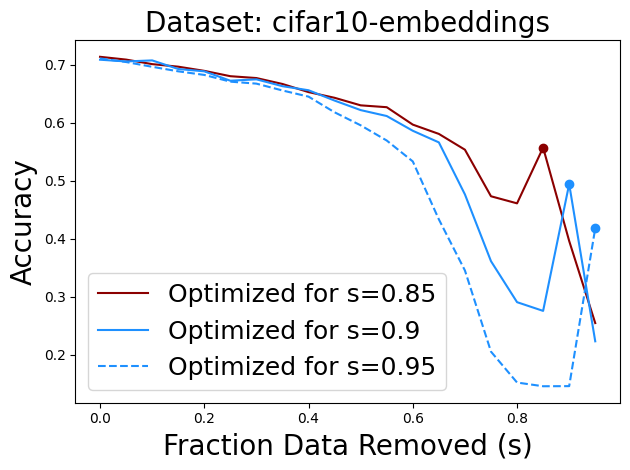

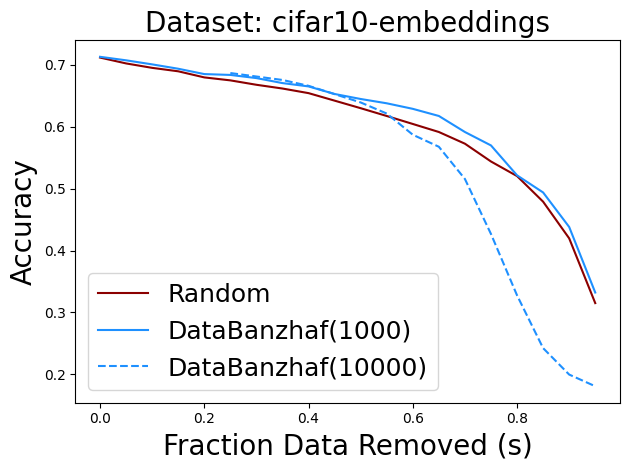

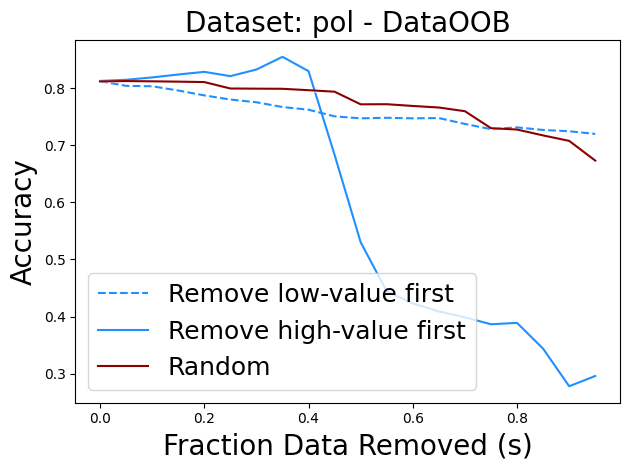

In [8]:
monotonicity_plot()
banzhaf_plot()
oob_plot()

## Generate figures

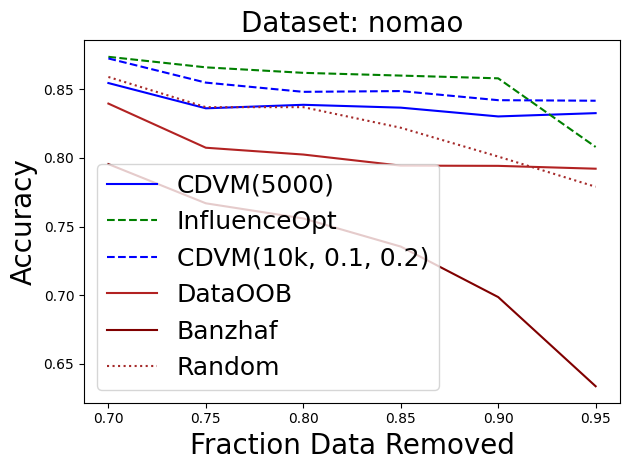

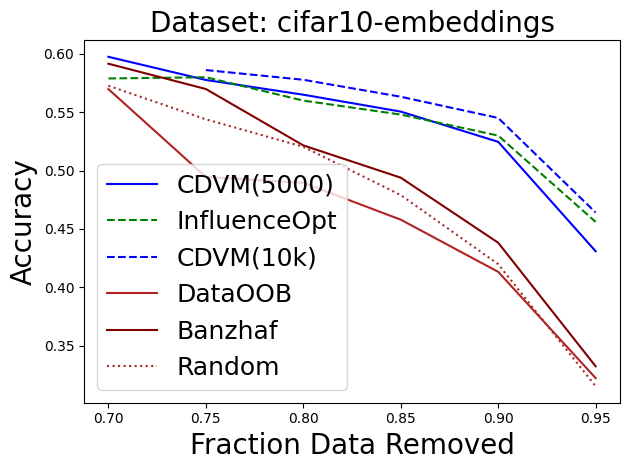

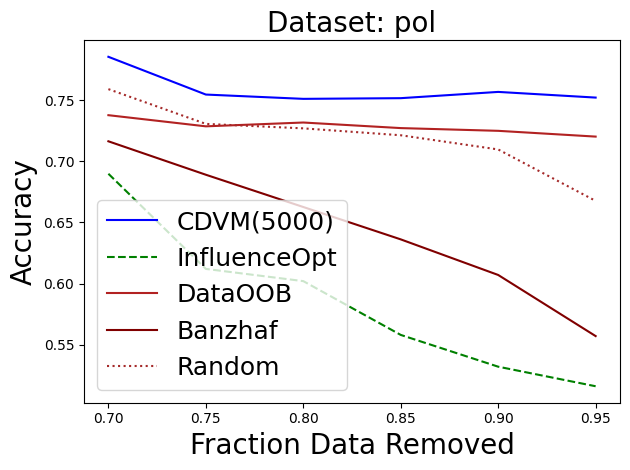

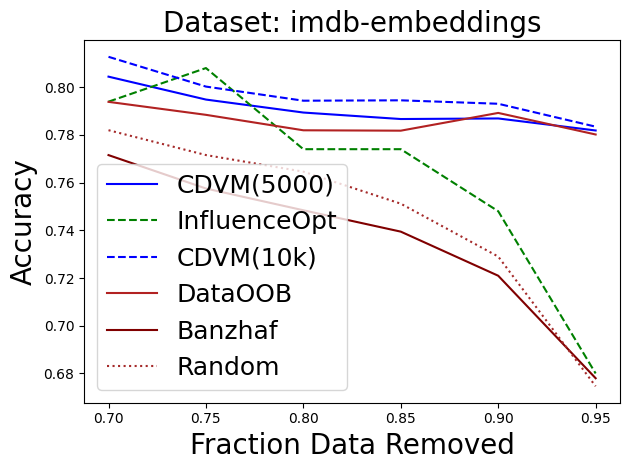

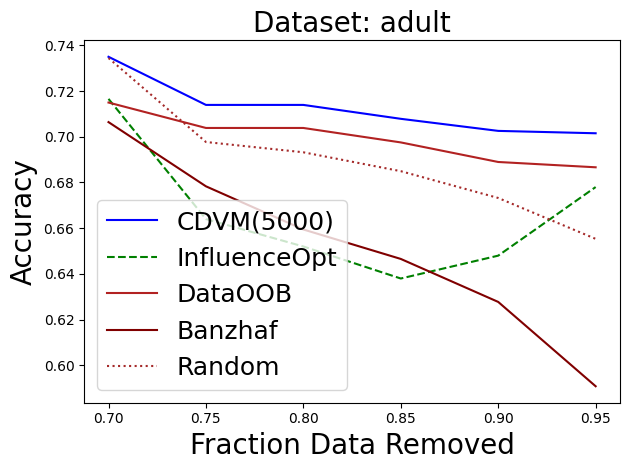

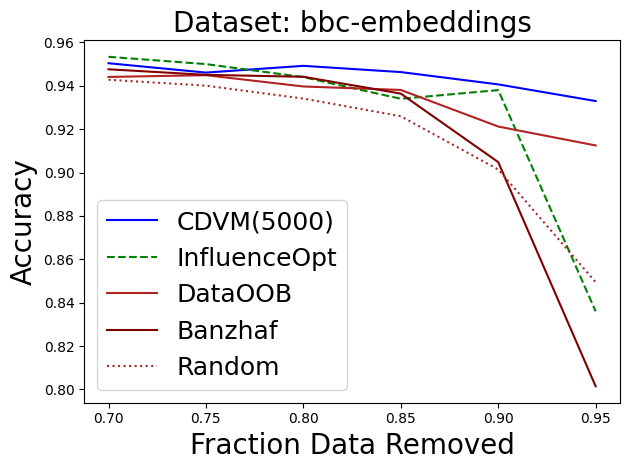

In [9]:
make_final_plot("nomao")
make_final_plot("cifar10-embeddings")
make_final_plot("pol")
make_final_plot("imdb-embeddings")
make_final_plot("adult")
make_final_plot("bbc-embeddings")